In [8]:
from pathlib import Path
import json
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
import neurokit2 as nk

from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import skew, kurtosis

warnings.filterwarnings("ignore")

print("NeuroKit2 version:", nk.__version__)

NeuroKit2 version: 0.2.13


In [9]:
PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "ptb-diagnostic-ecg-database-1.0.0"

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FEATURE_DIR = DATA_DIR / "features"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

detection_path = PROCESSED_DIR / "ptb_detection_records.csv"
preprocessing_config_path = TABLE_DIR / "notebook2_preprocessing_config.json"
segmentation_config_path = TABLE_DIR / "notebook3_segmentation_config.json"

print("Project directory:", PROJECT_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("Detection file exists:", detection_path.exists())
print("Preprocessing config exists:", preprocessing_config_path.exists())
print("Segmentation config exists:", segmentation_config_path.exists())

if not detection_path.exists():
    raise FileNotFoundError("ptb_detection_records.csv not found. Please run Notebook 1 first.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Dataset exists: True
Detection file exists: True
Preprocessing config exists: True
Segmentation config exists: True


In [10]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [11]:
detection_df = pd.read_csv(detection_path)

print("Detection dataset shape:", detection_df.shape)

print("\nRecord-level class distribution:")
display(detection_df["mi_detected"].value_counts())

print("\nPatient-level class distribution:")
display(
    detection_df
    .groupby("patient_id")["mi_detected"]
    .agg(lambda x: x.mode().iloc[0])
    .value_counts()
)

display(detection_df.head())

Detection dataset shape: (448, 15)

Record-level class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Patient-level class distribution:


mi_detected
1    148
0     52
Name: count, dtype: int64

,patient_id,record_id,record_path,age,sex,reason_for_admission,raw_localization,fs,n_sig,sig_len,duration_sec,comments_text,mi_detected,healthy_control,broad_group
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,38400,38.4,age: 81 | sex: female | ECG date: 01/10/1990 |...,1,0,Myocardial Infarction
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 18/10/1990 |...,1,0,Myocardial Infarction
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,58.0,female,Myocardial infarction,anterior,1000,15,115200,115.2,age: 58 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,63.0,male,Myocardial infarction,infero-lateral+infero-postero-lateral+posterio...,1000,15,115200,115.2,age: 63 | sex: male | ECG date: 18/10/1990 | D...,1,0,Myocardial Infarction


In [12]:
if preprocessing_config_path.exists():
    with open(preprocessing_config_path, "r", encoding="utf-8") as f:
        PREPROCESSING_CONFIG = json.load(f)
else:
    PREPROCESSING_CONFIG = {
        "bandpass_low_hz": 0.5,
        "bandpass_high_hz": 40.0,
        "notch_hz": 50.0,
        "notch_quality_factor": 30.0,
        "apply_notch": True,
        "normalization": "per_lead_z_score"
    }

if segmentation_config_path.exists():
    with open(segmentation_config_path, "r", encoding="utf-8") as f:
        SEGMENTATION_CONFIG = json.load(f)
else:
    SEGMENTATION_CONFIG = {
        "rpeak_detection_library": "NeuroKit2",
        "rpeak_detection_method": "neurokit",
        "correct_artifacts": True,
        "rpeak_lead": "ii",
        "pre_r_sec": 0.2,
        "post_r_sec": 0.4,
        "beat_window_sec": 0.6,
        "description": "Each beat is segmented from 0.2 s before to 0.4 s after the detected R-peak."
    }

print("Preprocessing config:")
print(json.dumps(PREPROCESSING_CONFIG, indent=4))

print("\nSegmentation config:")
print(json.dumps(SEGMENTATION_CONFIG, indent=4))

Preprocessing config:
{
    "bandpass_low_hz": 0.5,
    "bandpass_high_hz": 40.0,
    "notch_hz": 50.0,
    "notch_quality_factor": 30.0,
    "apply_notch": true,
    "normalization": "per_lead_z_score"
}

Segmentation config:
{
    "rpeak_detection_library": "NeuroKit2",
    "rpeak_detection_method": "neurokit",
    "correct_artifacts": true,
    "rpeak_lead": "ii",
    "pre_r_sec": 0.2,
    "post_r_sec": 0.4,
    "beat_window_sec": 0.6,
    "description": "Each beat is segmented from 0.2 s before to 0.4 s after the detected R-peak."
}


In [13]:
STANDARD_12_LEADS = [
    "i", "ii", "iii",
    "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6"
]

LEAD_DISPLAY_NAMES = {
    "i": "I",
    "ii": "II",
    "iii": "III",
    "avr": "aVR",
    "avl": "aVL",
    "avf": "aVF",
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "v6": "V6"
}

LEAD_GROUPS = {
    "limb": ["i", "ii", "iii", "avr", "avl", "avf"],
    "chest": ["v1", "v2", "v3", "v4", "v5", "v6"],
    "inferior": ["ii", "iii", "avf"],
    "anterior": ["v1", "v2", "v3", "v4"],
    "lateral": ["i", "avl", "v5", "v6"]
}

print("Standard 12 leads:")
print(STANDARD_12_LEADS)

print("\nLead groups:")
for group, leads in LEAD_GROUPS.items():
    print(group, ":", leads)

Standard 12 leads:
['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']

Lead groups:
limb : ['i', 'ii', 'iii', 'avr', 'avl', 'avf']
chest : ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']
inferior : ['ii', 'iii', 'avf']
anterior : ['v1', 'v2', 'v3', 'v4']
lateral : ['i', 'avl', 'v5', 'v6']


# Part A — ECG loading, preprocessing, and segmentation

In [14]:
def load_ecg_record(record_path_relative):
    """
    Load one ECG record using WFDB.
    """
    record_path = PROJECT_DIR / record_path_relative

    signal, fields = wfdb.rdsamp(str(record_path))

    lead_names = [str(ch).lower() for ch in fields["sig_name"]]
    fs = fields["fs"]

    record_info = {
        "fs": fs,
        "lead_names": lead_names,
        "units": fields.get("units", None),
        "n_samples": signal.shape[0],
        "n_channels": signal.shape[1],
        "duration_sec": signal.shape[0] / fs
    }

    return signal, fs, lead_names, record_info

In [15]:
def select_standard_12_leads(signal, lead_names):
    """
    Select and reorder ECG signal to standard 12-lead order:
    I, II, III, aVR, aVL, aVF, V1-V6.
    """
    lead_to_idx = {lead.lower(): idx for idx, lead in enumerate(lead_names)}

    missing_leads = [
        lead for lead in STANDARD_12_LEADS
        if lead not in lead_to_idx
    ]

    if len(missing_leads) > 0:
        raise ValueError(f"Missing leads: {missing_leads}")

    selected_indices = [lead_to_idx[lead] for lead in STANDARD_12_LEADS]
    selected_signal = signal[:, selected_indices]

    return selected_signal, STANDARD_12_LEADS

In [18]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def notch_filter(signal, fs, notch_freq=50.0, quality_factor=30.0):
    """
    Zero-phase notch filter for powerline interference.
    """
    b, a = iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )

    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def zscore_normalize_per_lead(signal, eps=1e-8):
    """
    Per-lead z-score normalization.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    normalized = (signal - mean) / (std + eps)

    return normalized, mean, std


def preprocess_ecg_signal(signal, fs, config=PREPROCESSING_CONFIG):
    """
    Apply ECG preprocessing:
    1. Bandpass filtering
    2. Optional notch filtering
    3. Per-lead z-score normalization
    """
    filtered = bandpass_filter(
        signal,
        fs,
        lowcut=config["bandpass_low_hz"],
        highcut=config["bandpass_high_hz"],
        order=4
    )

    if config["apply_notch"]:
        filtered = notch_filter(
            filtered,
            fs,
            notch_freq=config["notch_hz"],
            quality_factor=config["notch_quality_factor"]
        )

    normalized, mean_per_lead, std_per_lead = zscore_normalize_per_lead(filtered)

    preprocessing_info = {
        "filtered_mean_per_lead": mean_per_lead,
        "filtered_std_per_lead": std_per_lead,
        "normalized_mean_per_lead": np.mean(normalized, axis=0),
        "normalized_std_per_lead": np.std(normalized, axis=0)
    }

    return filtered, normalized, preprocessing_info

In [19]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def notch_filter(signal, fs, notch_freq=50.0, quality_factor=30.0):
    """
    Zero-phase notch filter for powerline interference.
    """
    b, a = iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )

    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def zscore_normalize_per_lead(signal, eps=1e-8):
    """
    Per-lead z-score normalization.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    normalized = (signal - mean) / (std + eps)

    return normalized, mean, std


def preprocess_ecg_signal(signal, fs, config=PREPROCESSING_CONFIG):
    """
    Apply ECG preprocessing:
    1. Bandpass filtering
    2. Optional notch filtering
    3. Per-lead z-score normalization
    """
    filtered = bandpass_filter(
        signal,
        fs,
        lowcut=config["bandpass_low_hz"],
        highcut=config["bandpass_high_hz"],
        order=4
    )

    if config["apply_notch"]:
        filtered = notch_filter(
            filtered,
            fs,
            notch_freq=config["notch_hz"],
            quality_factor=config["notch_quality_factor"]
        )

    normalized, mean_per_lead, std_per_lead = zscore_normalize_per_lead(filtered)

    preprocessing_info = {
        "filtered_mean_per_lead": mean_per_lead,
        "filtered_std_per_lead": std_per_lead,
        "normalized_mean_per_lead": np.mean(normalized, axis=0),
        "normalized_std_per_lead": np.std(normalized, axis=0)
    }

    return filtered, normalized, preprocessing_info

In [20]:
def segment_beats_around_rpeaks(
    signal_12lead,
    r_peaks,
    fs,
    pre_r_sec=0.2,
    post_r_sec=0.4
):
    """
    Segment 12-lead ECG beats around detected R-peaks / QRS anchors.

    Output shape:
    n_valid_beats × n_samples_per_beat × n_leads
    """
    pre_samples = int(pre_r_sec * fs)
    post_samples = int(post_r_sec * fs)

    beats = []
    valid_r_peaks = []

    for r in r_peaks:
        start = r - pre_samples
        end = r + post_samples

        if start < 0 or end > signal_12lead.shape[0]:
            continue

        beat = signal_12lead[start:end, :]
        beats.append(beat)
        valid_r_peaks.append(r)

    if len(beats) == 0:
        beats = np.empty((0, pre_samples + post_samples, signal_12lead.shape[1]))
    else:
        beats = np.stack(beats, axis=0)

    valid_r_peaks = np.array(valid_r_peaks, dtype=int)
    beat_time = np.arange(-pre_samples, post_samples) / fs

    return beats, valid_r_peaks, beat_time

In [21]:
def summarize_rhythm(r_peaks, fs, signal_length):
    """
    Extract rhythm-related features from detected R-peaks.
    """
    duration_sec = signal_length / fs
    n_peaks = len(r_peaks)

    features = {
        "rhythm_n_detected_rpeaks": n_peaks,
        "rhythm_duration_sec": duration_sec
    }

    if n_peaks >= 2:
        rr_sec = np.diff(r_peaks) / fs

        hr_values = 60 / rr_sec

        features.update({
            "rhythm_hr_count": n_peaks / duration_sec * 60,
            "rhythm_hr_mean": np.mean(hr_values),
            "rhythm_hr_median": np.median(hr_values),
            "rhythm_hr_std": np.std(hr_values),
            "rhythm_rr_mean": np.mean(rr_sec),
            "rhythm_rr_median": np.median(rr_sec),
            "rhythm_rr_std": np.std(rr_sec),
            "rhythm_rr_min": np.min(rr_sec),
            "rhythm_rr_max": np.max(rr_sec),
            "rhythm_rr_range": np.max(rr_sec) - np.min(rr_sec),
            "rhythm_rmssd": np.sqrt(np.mean(np.diff(rr_sec) ** 2)) if len(rr_sec) >= 2 else np.nan,
            "rhythm_pnn50": np.mean(np.abs(np.diff(rr_sec)) > 0.05) if len(rr_sec) >= 2 else np.nan
        })
    else:
        features.update({
            "rhythm_hr_count": np.nan,
            "rhythm_hr_mean": np.nan,
            "rhythm_hr_median": np.nan,
            "rhythm_hr_std": np.nan,
            "rhythm_rr_mean": np.nan,
            "rhythm_rr_median": np.nan,
            "rhythm_rr_std": np.nan,
            "rhythm_rr_min": np.nan,
            "rhythm_rr_max": np.nan,
            "rhythm_rr_range": np.nan,
            "rhythm_rmssd": np.nan,
            "rhythm_pnn50": np.nan
        })

    return features

# Part B — Statistical features

In [22]:
def safe_entropy(x, bins=50, eps=1e-12):
    """
    Compute histogram-based entropy.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    hist, _ = np.histogram(x, bins=bins, density=False)

    if hist.sum() == 0:
        return np.nan

    p = hist / hist.sum()
    p = p[p > 0]

    return -np.sum(p * np.log2(p + eps))


def zero_crossing_rate(x):
    """
    Compute zero-crossing rate.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    return np.mean(np.diff(np.signbit(x)))


def compute_statistical_features_1d(x, prefix):
    """
    Compute statistical features from one 1D signal.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {f"{prefix}_{name}": np.nan for name in [
            "mean", "median", "std", "var", "min", "max", "range",
            "rms", "energy", "abs_mean", "iqr", "skewness",
            "kurtosis", "entropy", "zcr"
        ]}

    features = {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_median": np.median(x),
        f"{prefix}_std": np.std(x),
        f"{prefix}_var": np.var(x),
        f"{prefix}_min": np.min(x),
        f"{prefix}_max": np.max(x),
        f"{prefix}_range": np.max(x) - np.min(x),
        f"{prefix}_rms": np.sqrt(np.mean(x ** 2)),
        f"{prefix}_energy": np.mean(x ** 2),
        f"{prefix}_abs_mean": np.mean(np.abs(x)),
        f"{prefix}_iqr": np.percentile(x, 75) - np.percentile(x, 25),
        f"{prefix}_skewness": skew(x) if len(x) > 2 else np.nan,
        f"{prefix}_kurtosis": kurtosis(x) if len(x) > 3 else np.nan,
        f"{prefix}_entropy": safe_entropy(x),
        f"{prefix}_zcr": zero_crossing_rate(x)
    }

    return features

In [23]:
# Cell 14
def extract_full_signal_statistical_features(normalized_12lead, lead_names):
    """
    Extract statistical features from the full normalized ECG signal for each lead.
    """
    features = {}

    for lead_idx, lead_name in enumerate(lead_names):
        x = normalized_12lead[:, lead_idx]
        prefix = f"{lead_name}_stat"
        features.update(compute_statistical_features_1d(x, prefix))

    return features

# Part C — Morphology features from segmented beats

In [24]:
def get_window_indices(beat_time, start_sec, end_sec):
    """
    Return indices within a time window.
    """
    return np.where((beat_time >= start_sec) & (beat_time < end_sec))[0]


MORPHOLOGY_WINDOWS = {
    "baseline": (-0.20, -0.12),
    "q_region": (-0.06, -0.005),
    "qrs_region": (-0.06, 0.08),
    "anchor_region": (-0.03, 0.03),
    "s_region": (0.005, 0.08),
    "st_region": (0.08, 0.12),
    "st_slope_region": (0.08, 0.16),
    "t_region": (0.12, 0.35)
}

print("Morphology windows:")
for name, window in MORPHOLOGY_WINDOWS.items():
    print(name, ":", window)

Morphology windows:
baseline : (-0.2, -0.12)
q_region : (-0.06, -0.005)
qrs_region : (-0.06, 0.08)
anchor_region : (-0.03, 0.03)
s_region : (0.005, 0.08)
st_region : (0.08, 0.12)
st_slope_region : (0.08, 0.16)
t_region : (0.12, 0.35)


In [25]:
def compute_qrs_width_proxy(signal_window, time_window, baseline, eps=1e-8):
    """
    Approximate QRS width using half of maximum absolute QRS deflection.
    This is not a clinical-grade QRS width measurement.
    """
    centered = signal_window - baseline

    if len(centered) == 0:
        return np.nan

    max_abs = np.max(np.abs(centered))

    if max_abs < eps:
        return np.nan

    mask = np.abs(centered) >= 0.5 * max_abs

    if not np.any(mask):
        return np.nan

    selected_time = time_window[mask]

    return selected_time[-1] - selected_time[0]


def compute_st_slope(st_signal, st_time):
    """
    Approximate ST slope using linear regression within the ST slope region.
    """
    if len(st_signal) < 2:
        return np.nan

    try:
        slope = np.polyfit(st_time, st_signal, 1)[0]
        return slope
    except Exception:
        return np.nan


def extract_morphology_features_one_beat_one_lead(beat_signal, beat_time):
    """
    Extract approximate morphology features from one beat and one lead.

    Important:
    These are approximate morphology features based on fixed windows
    relative to the detected QRS anchor, not clinical-grade fiducial measurements.
    """
    idx_baseline = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["baseline"])
    idx_q = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["q_region"])
    idx_qrs = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["qrs_region"])
    idx_anchor = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["anchor_region"])
    idx_s = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["s_region"])
    idx_st = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["st_region"])
    idx_st_slope = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["st_slope_region"])
    idx_t = get_window_indices(beat_time, *MORPHOLOGY_WINDOWS["t_region"])

    baseline = np.mean(beat_signal[idx_baseline]) if len(idx_baseline) > 0 else 0.0

    q_values = beat_signal[idx_q] - baseline if len(idx_q) > 0 else np.array([np.nan])
    qrs_values = beat_signal[idx_qrs] - baseline if len(idx_qrs) > 0 else np.array([np.nan])
    anchor_values = beat_signal[idx_anchor] - baseline if len(idx_anchor) > 0 else np.array([np.nan])
    s_values = beat_signal[idx_s] - baseline if len(idx_s) > 0 else np.array([np.nan])
    st_values = beat_signal[idx_st] - baseline if len(idx_st) > 0 else np.array([np.nan])
    st_slope_values = beat_signal[idx_st_slope] - baseline if len(idx_st_slope) > 0 else np.array([np.nan])
    t_values = beat_signal[idx_t] - baseline if len(idx_t) > 0 else np.array([np.nan])

    # T-wave signed amplitude: value with maximum absolute magnitude in T window
    if np.all(np.isnan(t_values)):
        t_amp = np.nan
    else:
        t_amp = t_values[np.nanargmax(np.abs(t_values))]

    # Anchor signed amplitude: value with maximum absolute magnitude around anchor window
    if np.all(np.isnan(anchor_values)):
        anchor_amp = np.nan
    else:
        anchor_amp = anchor_values[np.nanargmax(np.abs(anchor_values))]

    dt = np.mean(np.diff(beat_time)) if len(beat_time) > 1 else np.nan

    qrs_width = compute_qrs_width_proxy(
        beat_signal[idx_qrs],
        beat_time[idx_qrs],
        baseline
    ) if len(idx_qrs) > 0 else np.nan

    st_slope = compute_st_slope(
        st_slope_values,
        beat_time[idx_st_slope]
    ) if len(idx_st_slope) > 1 else np.nan

    features = {
        "baseline": baseline,
        "q_amp": np.nanmin(q_values),
        "qrs_anchor_amp": anchor_amp,
        "qrs_max_amp": np.nanmax(qrs_values),
        "qrs_min_amp": np.nanmin(qrs_values),
        "qrs_ptp": np.nanmax(qrs_values) - np.nanmin(qrs_values),
        "qrs_area": np.nansum(np.abs(qrs_values)) * dt,
        "qrs_width_proxy": qrs_width,
        "s_amp": np.nanmin(s_values),
        "st_level": np.nanmean(st_values),
        "st_slope": st_slope,
        "t_amp": t_amp,
        "t_max_amp": np.nanmax(t_values),
        "t_min_amp": np.nanmin(t_values),
        "t_area": np.nansum(np.abs(t_values)) * dt
    }

    return features

In [26]:
def aggregate_values(values, prefix):
    """
    Aggregate a list/array of values into mean, median, std, min, max.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan
        }

    return {
        f"{prefix}_mean": np.mean(values),
        f"{prefix}_median": np.median(values),
        f"{prefix}_std": np.std(values),
        f"{prefix}_min": np.min(values),
        f"{prefix}_max": np.max(values)
    }


def extract_morphology_features_from_beats(beats, beat_time, lead_names):
    """
    Extract morphology features from segmented beats.

    For each lead:
    1. Extract morphology features from each beat.
    2. Aggregate features across beats.
    """
    features = {}

    if beats.shape[0] == 0:
        return features

    n_beats, n_samples, n_leads = beats.shape

    for lead_idx, lead_name in enumerate(lead_names):
        per_feature_values = {}

        for beat_idx in range(n_beats):
            beat_signal = beats[beat_idx, :, lead_idx]

            beat_features = extract_morphology_features_one_beat_one_lead(
                beat_signal,
                beat_time
            )

            for feature_name, value in beat_features.items():
                per_feature_values.setdefault(feature_name, []).append(value)

        for feature_name, values in per_feature_values.items():
            prefix = f"{lead_name}_morph_{feature_name}"
            features.update(aggregate_values(values, prefix))

    return features

# Part D — Ratio, lead-group, and contrast features

In [27]:
def add_ratio_features(features, lead_names, eps=1e-8):
    """
    Add morphology ratio features for each lead.

    Ratios are useful because they reduce the effect of absolute amplitude scale.
    """
    for lead in lead_names:
        qrs_ptp = features.get(f"{lead}_morph_qrs_ptp_mean", np.nan)
        st_level = features.get(f"{lead}_morph_st_level_mean", np.nan)
        t_amp = features.get(f"{lead}_morph_t_amp_mean", np.nan)
        q_amp = features.get(f"{lead}_morph_q_amp_mean", np.nan)
        s_amp = features.get(f"{lead}_morph_s_amp_mean", np.nan)
        anchor_amp = features.get(f"{lead}_morph_qrs_anchor_amp_mean", np.nan)

        denom_qrs = np.abs(qrs_ptp) + eps
        denom_anchor = np.abs(anchor_amp) + eps

        features[f"{lead}_ratio_st_to_qrs"] = st_level / denom_qrs
        features[f"{lead}_ratio_abs_st_to_qrs"] = np.abs(st_level) / denom_qrs

        features[f"{lead}_ratio_t_to_qrs"] = t_amp / denom_qrs
        features[f"{lead}_ratio_abs_t_to_qrs"] = np.abs(t_amp) / denom_qrs

        features[f"{lead}_ratio_q_to_anchor"] = q_amp / denom_anchor
        features[f"{lead}_ratio_s_to_anchor"] = s_amp / denom_anchor

    return features

In [28]:
def add_lead_group_features(features, lead_groups=LEAD_GROUPS):
    """
    Add lead-group aggregated features.

    These features summarize information from clinically meaningful lead groups:
    limb, chest, inferior, anterior, lateral.
    """
    suffixes_to_group = [
        "stat_rms",
        "stat_energy",
        "stat_abs_mean",
        "stat_std",
        "stat_zcr",
        "morph_qrs_ptp_mean",
        "morph_qrs_area_mean",
        "morph_qrs_width_proxy_mean",
        "morph_st_level_mean",
        "morph_st_slope_mean",
        "morph_t_amp_mean",
        "morph_t_area_mean",
        "morph_qrs_anchor_amp_mean",
        "ratio_st_to_qrs",
        "ratio_abs_st_to_qrs",
        "ratio_t_to_qrs",
        "ratio_abs_t_to_qrs"
    ]

    group_mean_lookup = {}

    for group_name, leads in lead_groups.items():
        for suffix in suffixes_to_group:
            values = []

            for lead in leads:
                key = f"{lead}_{suffix}"

                if key in features and np.isfinite(features[key]):
                    values.append(features[key])

            values = np.asarray(values, dtype=float)

            if len(values) == 0:
                mean_value = np.nan
                std_value = np.nan
            else:
                mean_value = np.mean(values)
                std_value = np.std(values)

            features[f"{group_name}_group_{suffix}_mean"] = mean_value
            features[f"{group_name}_group_{suffix}_std"] = std_value

            group_mean_lookup[(group_name, suffix)] = mean_value

    return features, group_mean_lookup

In [29]:
# Cell 20
def add_lead_group_contrast_features(features, group_mean_lookup):
    """
    Add contrast features between lead groups.

    These features compare anatomical lead groups and are useful for
    later lead contribution analysis.
    """
    contrast_pairs = [
        ("chest", "limb"),
        ("anterior", "inferior"),
        ("anterior", "lateral"),
        ("inferior", "lateral"),
        ("lateral", "chest")
    ]

    suffixes = [
        "stat_rms",
        "stat_abs_mean",
        "morph_qrs_ptp_mean",
        "morph_st_level_mean",
        "morph_t_amp_mean",
        "ratio_abs_st_to_qrs",
        "ratio_abs_t_to_qrs"
    ]

    eps = 1e-8

    for group_a, group_b in contrast_pairs:
        for suffix in suffixes:
            a = group_mean_lookup.get((group_a, suffix), np.nan)
            b = group_mean_lookup.get((group_b, suffix), np.nan)

            features[f"contrast_{group_a}_minus_{group_b}_{suffix}"] = a - b
            features[f"contrast_{group_a}_over_{group_b}_{suffix}"] = a / (np.abs(b) + eps)

    return features

# Part E — Full feature extraction for one record

In [32]:
def extract_features_from_record(row, min_valid_beats=3):
    """
    Full feature extraction pipeline for one ECG record.
    """
    metadata = {
        "patient_id": row["patient_id"],
        "record_id": row["record_id"],
        "record_path": row["record_path"],
        "mi_detected": row["mi_detected"],
        "healthy_control": row["healthy_control"],
        "reason_for_admission": row["reason_for_admission"]
    }

    try:
        raw_signal, fs, lead_names, record_info = load_ecg_record(row["record_path"])
        raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

        filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
            raw_12lead,
            fs,
            PREPROCESSING_CONFIG
        )

        rpeak_lead = SEGMENTATION_CONFIG["rpeak_lead"]
        rpeak_lead_idx = selected_leads.index(rpeak_lead)

        lead_signal_for_detection = filtered_12lead[:, rpeak_lead_idx]

        best_detection, candidates = detect_r_peaks_neurokit_best_direction(
            lead_signal_for_detection,
            fs,
            method=SEGMENTATION_CONFIG["rpeak_detection_method"],
            correct_artifacts=SEGMENTATION_CONFIG["correct_artifacts"]
        )

        r_peaks = best_detection["r_peaks"]

        beats, valid_r_peaks, beat_time = segment_beats_around_rpeaks(
            normalized_12lead,
            r_peaks,
            fs,
            pre_r_sec=SEGMENTATION_CONFIG["pre_r_sec"],
            post_r_sec=SEGMENTATION_CONFIG["post_r_sec"]
        )

        if beats.shape[0] < min_valid_beats:
            raise ValueError(f"Too few valid beats: {beats.shape[0]}")

        features = {}

        # Basic record information
        features.update({
            "fs": fs,
            "duration_sec": record_info["duration_sec"],
            "n_samples": record_info["n_samples"],
            "n_channels_original": record_info["n_channels"],
            "rpeak_detection_direction": best_detection["direction"],
            "n_detected_rpeaks": len(r_peaks),
            "n_valid_beats": beats.shape[0],
            "beat_length_samples": beats.shape[1]
        })

        # Rhythm features
        rhythm_features = summarize_rhythm(
            r_peaks,
            fs,
            signal_length=normalized_12lead.shape[0]
        )
        features.update(rhythm_features)

        # Full-signal statistical features
        stat_features = extract_full_signal_statistical_features(
            normalized_12lead,
            selected_leads
        )
        features.update(stat_features)

        # Morphology features from segmented beats
        morph_features = extract_morphology_features_from_beats(
            beats,
            beat_time,
            selected_leads
        )
        features.update(morph_features)

        # Ratio features
        features = add_ratio_features(features, selected_leads)

        # Lead-group features
        features, group_mean_lookup = add_lead_group_features(features)

        # Contrast features
        features = add_lead_group_contrast_features(features, group_mean_lookup)

        output = {
            **metadata,
            "extraction_status": "success",
            "error_message": "",
            **features
        }

        return output

    except Exception as e:
        output = {
            **metadata,
            "extraction_status": "failed",
            "error_message": str(e)
        }

        return output

In [37]:
def detect_r_peaks_neurokit_best_direction(
    ecg_lead,
    fs,
    method="neurokit",
    correct_artifacts=True,
    min_hr=35,
    max_hr=180
):
    """
    Detect R-peaks / QRS anchor points using NeuroKit2.

    The function tries both:
    1. original ECG lead
    2. inverted ECG lead

    This helps handle records where QRS morphology is inverted.
    """
    candidates = []

    for direction_name, signal_used in [
        ("original", ecg_lead),
        ("inverted", -ecg_lead)
    ]:
        try:
            cleaned = nk.ecg_clean(
                signal_used,
                sampling_rate=fs,
                method=method
            )

            _, info = nk.ecg_peaks(
                cleaned,
                sampling_rate=fs,
                method=method,
                correct_artifacts=correct_artifacts
            )

            r_peaks = np.array(info["ECG_R_Peaks"], dtype=int)

            duration_sec = len(ecg_lead) / fs
            hr_count = len(r_peaks) / duration_sec * 60 if duration_sec > 0 else np.nan

            if len(r_peaks) >= 3:
                rr_sec = np.diff(r_peaks) / fs
                rr_median = np.median(rr_sec)
                rr_std = np.std(rr_sec)
                hr_median = 60 / rr_median if rr_median > 0 else np.nan
            else:
                rr_std = np.inf
                hr_median = np.nan

            plausible_hr = (
                np.isfinite(hr_count)
                and hr_count >= min_hr
                and hr_count <= max_hr
            )

            candidates.append({
                "direction": direction_name,
                "cleaned": cleaned,
                "r_peaks": r_peaks,
                "n_peaks": len(r_peaks),
                "hr_count": hr_count,
                "hr_median": hr_median,
                "rr_std": rr_std,
                "plausible_hr": plausible_hr
            })

        except Exception as e:
            candidates.append({
                "direction": direction_name,
                "cleaned": signal_used,
                "r_peaks": np.array([], dtype=int),
                "n_peaks": 0,
                "hr_count": np.nan,
                "hr_median": np.nan,
                "rr_std": np.inf,
                "plausible_hr": False,
                "error": str(e)
            })

    candidates_sorted = sorted(
        candidates,
        key=lambda x: (
            x["plausible_hr"],
            x["n_peaks"],
            -x["rr_std"] if np.isfinite(x["rr_std"]) else -1e9
        ),
        reverse=True
    )

    best = candidates_sorted[0]

    return best, candidates


print("Function defined successfully:")
print(detect_r_peaks_neurokit_best_direction)

Function defined successfully:
<function detect_r_peaks_neurokit_best_direction at 0x000001A753651620>


In [38]:
# test one record
example_row = detection_df.iloc[0]

print("Example record:")
display(example_row[["patient_id", "record_id", "record_path", "reason_for_admission", "mi_detected"]])

example_features = extract_features_from_record(example_row)

print("Extraction status:", example_features["extraction_status"])
print("Error message:", example_features["error_message"])

print("Number of extracted fields:", len(example_features))

selected_keys = [
    "patient_id",
    "record_id",
    "mi_detected",
    "duration_sec",
    "n_detected_rpeaks",
    "n_valid_beats",
    "rhythm_hr_median",
    "rpeak_detection_direction",
    "ii_stat_rms",
    "ii_morph_qrs_ptp_mean",
    "ii_morph_st_level_mean",
    "ii_morph_t_amp_mean",
    "v5_morph_st_level_mean",
    "lateral_group_morph_st_level_mean_mean",
    "contrast_chest_minus_limb_stat_rms"
]

for key in selected_keys:
    print(key, ":", example_features.get(key, "not found"))

Example record:


patient_id                                                     patient001
record_id                                                        s0010_re
record_path             ptb-diagnostic-ecg-database-1.0.0\patient001\s...
reason_for_admission                                Myocardial infarction
mi_detected                                                             1
Name: 0, dtype: object

Extraction status: success
Error message: 
Number of extracted fields: 1422
patient_id : patient001
record_id : s0010_re
mi_detected : 1
duration_sec : 38.4
n_detected_rpeaks : 52
n_valid_beats : 51
rhythm_hr_median : 81.74386920980926
rpeak_detection_direction : original
ii_stat_rms : 0.999999918123654
ii_morph_qrs_ptp_mean : 3.8810139417113545
ii_morph_st_level_mean : -0.6907839568341567
ii_morph_t_amp_mean : -2.700071604652639
v5_morph_st_level_mean : -0.42077813036315187
lateral_group_morph_st_level_mean_mean : -0.6023534409035483
contrast_chest_minus_limb_stat_rms : 1.3552130417870956e-08


In [39]:
example_features_df = pd.DataFrame([example_features])

print("Example feature dataframe shape:", example_features_df.shape)

display(example_features_df.head())

Example feature dataframe shape: (1, 1422)


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_minus_chest_morph_qrs_ptp_mean,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,,1000,38.4,...,-0.881952,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658


# Visual explanation of morphology windows

In [40]:
# Re-run processing for visualization only
raw_signal, fs, lead_names, record_info = load_ecg_record(example_row["record_path"])
raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
    raw_12lead,
    fs,
    PREPROCESSING_CONFIG
)

rpeak_lead_idx = selected_leads.index(SEGMENTATION_CONFIG["rpeak_lead"])
lead_signal_for_detection = filtered_12lead[:, rpeak_lead_idx]

best_detection, _ = detect_r_peaks_neurokit_best_direction(
    lead_signal_for_detection,
    fs,
    method=SEGMENTATION_CONFIG["rpeak_detection_method"],
    correct_artifacts=SEGMENTATION_CONFIG["correct_artifacts"]
)

r_peaks = best_detection["r_peaks"]

beats, valid_r_peaks, beat_time = segment_beats_around_rpeaks(
    normalized_12lead,
    r_peaks,
    fs,
    pre_r_sec=SEGMENTATION_CONFIG["pre_r_sec"],
    post_r_sec=SEGMENTATION_CONFIG["post_r_sec"]
)

print("Beats shape:", beats.shape)

Beats shape: (51, 600, 12)


In [41]:
def plot_morphology_windows_on_average_beat(
    beats,
    beat_time,
    lead_names,
    lead_name="ii",
    output_path=None
):
    lead_idx = lead_names.index(lead_name.lower())

    avg_beat = np.mean(beats[:, :, lead_idx], axis=0)

    plt.figure(figsize=(12, 5))

    plt.plot(
        beat_time,
        avg_beat,
        color=PURPLE_DARK,
        linewidth=2.0,
        label="Average beat"
    )

    # Window shading
    window_styles = {
        "baseline": (PURPLE_VERY_LIGHT, "Baseline"),
        "qrs_region": (PURPLE_LIGHT, "QRS region"),
        "st_region": (PURPLE_MAIN, "ST region"),
        "t_region": (PURPLE_MID, "T region")
    }

    for window_name, (color, label) in window_styles.items():
        start, end = MORPHOLOGY_WINDOWS[window_name]
        plt.axvspan(start, end, color=color, alpha=0.35, label=label)

    plt.axvline(0, color=RED_SOFT, linestyle="--", linewidth=1.5, label="QRS anchor")

    plt.title(f"Morphology Feature Windows — Lead {LEAD_DISPLAY_NAMES[lead_name]}")
    plt.xlabel("Time relative to QRS anchor (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

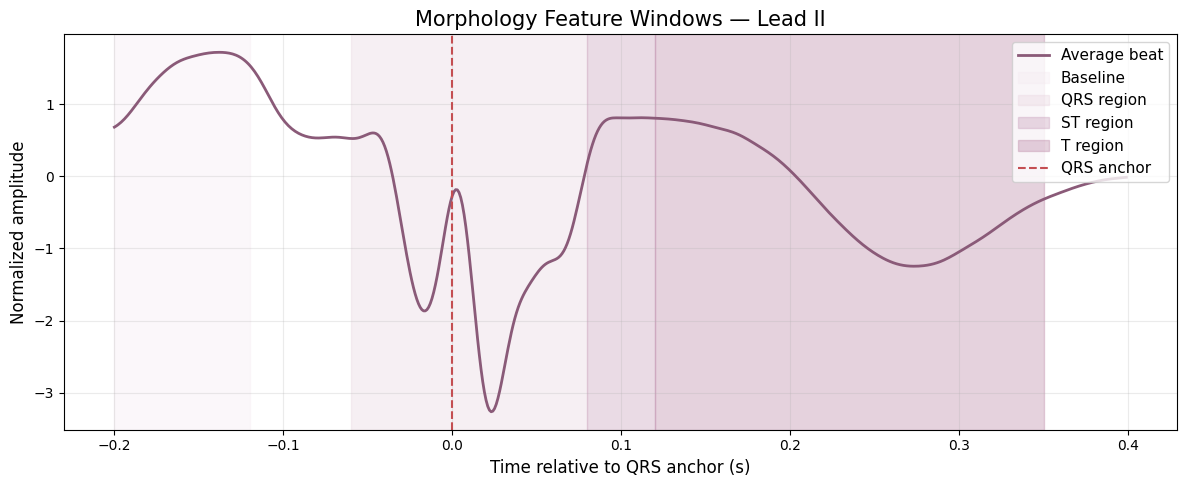

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook4_morphology_windows_lead_ii.png


In [42]:
fig_path = FIGURE_DIR / "notebook4_morphology_windows_lead_ii.png"

plot_morphology_windows_on_average_beat(
    beats,
    beat_time,
    selected_leads,
    lead_name="ii",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

# Run feature extraction on a small subset first

In [43]:
test_records_df = detection_df.head(10).copy()

test_outputs = []

for idx, row in test_records_df.iterrows():
    print("=" * 80)
    print(f"Processing test record {idx + 1}/{len(test_records_df)}:", row["patient_id"], row["record_id"])

    output = extract_features_from_record(row)
    test_outputs.append(output)

    print("Status:", output["extraction_status"])
    print("Error:", output["error_message"])
    print("Valid beats:", output.get("n_valid_beats", np.nan))
    print("HR median:", output.get("rhythm_hr_median", np.nan))

test_features_df = pd.DataFrame(test_outputs)

display(test_features_df[[
    "patient_id",
    "record_id",
    "mi_detected",
    "extraction_status",
    "error_message",
    "n_detected_rpeaks",
    "n_valid_beats",
    "rhythm_hr_median",
    "rpeak_detection_direction"
]])

Processing test record 1/10: patient001 s0010_re
Status: success
Error: 
Valid beats: 51
HR median: 81.74386920980926
Processing test record 2/10: patient001 s0014lre
Status: success
Error: 
Valid beats: 165
HR median: 86.33093525179856
Processing test record 3/10: patient001 s0016lre
Status: success
Error: 
Valid beats: 153
HR median: 79.7872340425532
Processing test record 4/10: patient002 s0015lre
Status: success
Error: 
Valid beats: 150
HR median: 78.53403141361257
Processing test record 5/10: patient003 s0017lre
Status: success
Error: 
Valid beats: 138
HR median: 72.28915662650603
Processing test record 6/10: patient004 s0020are
Status: success
Error: 
Valid beats: 157
HR median: 82.53094910591471
Processing test record 7/10: patient004 s0020bre
Status: success
Error: 
Valid beats: 154
HR median: 80.97165991902834
Processing test record 8/10: patient005 s0021are
Status: success
Error: 
Valid beats: 184
HR median: 95.54140127388536
Processing test record 9/10: patient005 s0021bre
S

,patient_id,record_id,mi_detected,extraction_status,error_message,n_detected_rpeaks,n_valid_beats,rhythm_hr_median,rpeak_detection_direction
0,patient001,s0010_re,1,success,,52,51,81.743869,original
1,patient001,s0014lre,1,success,,165,165,86.330935,inverted
2,patient001,s0016lre,1,success,,153,153,79.787234,inverted
3,patient002,s0015lre,1,success,,151,150,78.534031,original
4,patient003,s0017lre,1,success,,138,138,72.289157,original
5,patient004,s0020are,1,success,,158,157,82.530949,original
6,patient004,s0020bre,1,success,,155,154,80.971660,original
7,patient005,s0021are,1,success,,184,184,95.541401,original
8,patient005,s0021bre,1,success,,182,182,94.786730,original
9,patient005,s0025lre,1,success,,198,197,103.270224,original


In [44]:
# Cell 28
print("Test feature table shape:", test_features_df.shape)

print("\nExtraction status counts:")
display(test_features_df["extraction_status"].value_counts())

numeric_test_df = test_features_df.select_dtypes(include=[np.number])

print("\nNumeric missing values:", numeric_test_df.isna().sum().sum())
print("Numeric infinite values:", np.isinf(numeric_test_df.to_numpy()).sum())

print("\nValid beats summary:")
display(test_features_df["n_valid_beats"].describe())

print("\nHR summary:")
display(test_features_df["rhythm_hr_median"].describe())

Test feature table shape: (10, 1422)

Extraction status counts:


extraction_status
success    10
Name: count, dtype: int64


Numeric missing values: 0
Numeric infinite values: 0

Valid beats summary:


count     10.000000
mean     153.100000
std       40.189689
min       51.000000
25%      150.750000
50%      155.500000
75%      177.750000
max      197.000000
Name: n_valid_beats, dtype: float64


HR summary:


count     10.000000
mean      85.578619
std        9.443393
min       72.289157
25%       80.083341
50%       82.137409
75%       92.672781
max      103.270224
Name: rhythm_hr_median, dtype: float64

# Run feature extraction on all detection records

In [46]:
all_outputs = []

n_records = len(detection_df)

for idx, row in detection_df.iterrows():
    if (idx + 1) % 25 == 0 or idx == 0 or idx == n_records - 1:
        print(f"Processing {idx + 1}/{n_records}: {row['patient_id']} {row['record_id']}")

    output = extract_features_from_record(row)
    all_outputs.append(output)

features_df = pd.DataFrame(all_outputs)

print("Feature extraction completed.")
print("Feature table shape:", features_df.shape)

display(features_df.head())

Processing 1/448: patient001 s0010_re
Processing 25/448: patient010 s0042lre
Processing 50/448: patient018 s0059lre
Processing 75/448: patient026 s0088lre
Processing 100/448: patient033 s0121lre
Processing 125/448: patient041 s0132lre
Processing 150/448: patient047 s0167lre
Processing 175/448: patient057 s0198lre
Processing 200/448: patient072 s0237lre
Processing 225/448: patient078 s0259lre
Processing 250/448: patient084 s0289lre
Processing 275/448: patient091 s0408lre
Processing 300/448: patient097 s0394lre
Processing 325/448: patient121 s0311lre
Processing 350/448: patient169 s0328lre
Processing 375/448: patient198 s0415lre
Processing 400/448: patient240 s0468_re
Processing 425/448: patient270 s0507_re
Processing 448/448: patient294 s0559_re
Feature extraction completed.
Feature table shape: (448, 1422)


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_minus_chest_morph_qrs_ptp_mean,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,,1000,38.4,...,-0.881952,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,,1000,115.2,...,-0.547437,0.919469,-0.071970,-1.296162,-0.036523,0.432207,0.011147,1.290027,0.047875,1.497575
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,,1000,115.2,...,-0.581871,0.914905,-0.191350,-1.982390,0.611210,0.365668,0.019226,1.461171,0.034442,1.445004
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,1,0,Myocardial infarction,success,,1000,115.2,...,-0.045130,0.992804,-0.154674,-3.082995,0.024435,-0.989664,0.032816,3.750345,0.080275,1.202903
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,1,0,Myocardial infarction,success,,1000,115.2,...,1.033608,1.185153,-0.406936,-3.138080,-0.857880,0.563911,-0.032781,0.577757,-0.252801,0.530411


In [47]:
print("Feature table shape:", features_df.shape)

print("\nExtraction status counts:")
display(features_df["extraction_status"].value_counts())

print("\nClass distribution in feature table:")
display(features_df["mi_detected"].value_counts())

success_df = features_df[features_df["extraction_status"] == "success"].copy()
failed_df = features_df[features_df["extraction_status"] == "failed"].copy()

print("\nNumber of successful records:", len(success_df))
print("Number of failed records:", len(failed_df))

if len(failed_df) > 0:
    print("\nFailed records:")
    display(failed_df[["patient_id", "record_id", "record_path", "error_message"]].head(20))

Feature table shape: (448, 1422)

Extraction status counts:


extraction_status
success    448
Name: count, dtype: int64


Class distribution in feature table:


mi_detected
1    368
0     80
Name: count, dtype: int64


Number of successful records: 448
Number of failed records: 0


In [48]:
numeric_df = features_df.select_dtypes(include=[np.number])

numeric_missing = numeric_df.isna().sum().sum()
numeric_infinite = np.isinf(numeric_df.to_numpy()).sum()

print("Total numeric columns:", numeric_df.shape[1])
print("Numeric missing values:", numeric_missing)
print("Numeric infinite values:", numeric_infinite)

missing_by_column = numeric_df.isna().sum().sort_values(ascending=False)

print("\nTop columns with missing values:")
display(missing_by_column.head(20))

Total numeric columns: 1415
Numeric missing values: 0
Numeric infinite values: 0

Top columns with missing values:


mi_detected                 0
healthy_control             0
fs                          0
duration_sec                0
n_samples                   0
n_channels_original         0
n_detected_rpeaks           0
n_valid_beats               0
beat_length_samples         0
rhythm_n_detected_rpeaks    0
rhythm_duration_sec         0
rhythm_hr_count             0
rhythm_hr_mean              0
rhythm_hr_median            0
rhythm_hr_std               0
rhythm_rr_mean              0
rhythm_rr_median            0
rhythm_rr_std               0
rhythm_rr_min               0
rhythm_rr_max               0
dtype: int64

In [49]:
print("Valid beats summary:")
display(features_df["n_valid_beats"].describe())

print("\nDetected R-peaks summary:")
display(features_df["n_detected_rpeaks"].describe())

print("\nEstimated HR summary:")
display(features_df["rhythm_hr_median"].describe())

print("\nR-peak detection direction:")
display(features_df["rpeak_detection_direction"].value_counts())

Valid beats summary:


count    448.000000
mean     142.535714
std       34.185748
min       35.000000
25%      123.000000
50%      141.500000
75%      162.000000
max      269.000000
Name: n_valid_beats, dtype: float64


Detected R-peaks summary:


count    448.000000
mean     143.084821
std       34.249929
min       35.000000
25%      123.000000
50%      142.000000
75%      163.000000
max      269.000000
Name: n_detected_rpeaks, dtype: float64


Estimated HR summary:


count    448.000000
mean      76.341872
std       15.577180
min       43.478261
25%       65.288357
50%       74.719859
75%       85.500567
max      157.480315
Name: rhythm_hr_median, dtype: float64


R-peak detection direction:


rpeak_detection_direction
original    291
inverted    157
Name: count, dtype: int64

In [60]:
# =========================
# Check high/low HR records
# =========================

hr_low_threshold = 40
hr_high_threshold = 140

hr_outliers_df = features_df[
    (features_df["rhythm_hr_median"] < hr_low_threshold) |
    (features_df["rhythm_hr_median"] > hr_high_threshold)
].copy()

print("Number of HR outlier records:", len(hr_outliers_df))

display(
    hr_outliers_df[
        [
            "patient_id",
            "record_id",
            "mi_detected",
            "reason_for_admission",
            "n_detected_rpeaks",
            "n_valid_beats",
            "rhythm_hr_median",
            "rpeak_detection_direction"
        ]
    ].sort_values("rhythm_hr_median", ascending=False)
)

Number of HR outlier records: 2


,patient_id,record_id,mi_detected,reason_for_admission,n_detected_rpeaks,n_valid_beats,rhythm_hr_median,rpeak_detection_direction
312,patient101,s0410lre,1,Myocardial infarction,249,249,157.480315,inverted
189,patient067,s0227lre,1,Myocardial infarction,269,269,140.515222,original


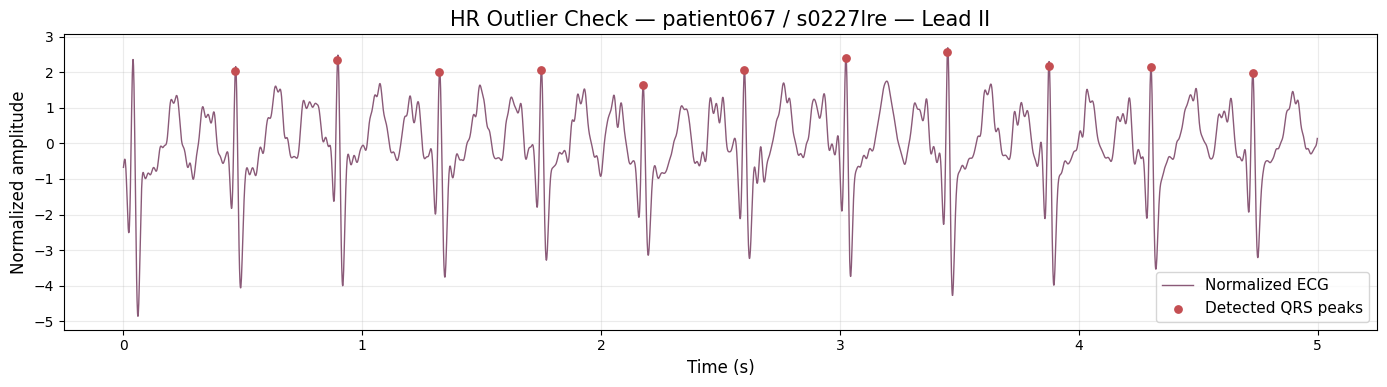

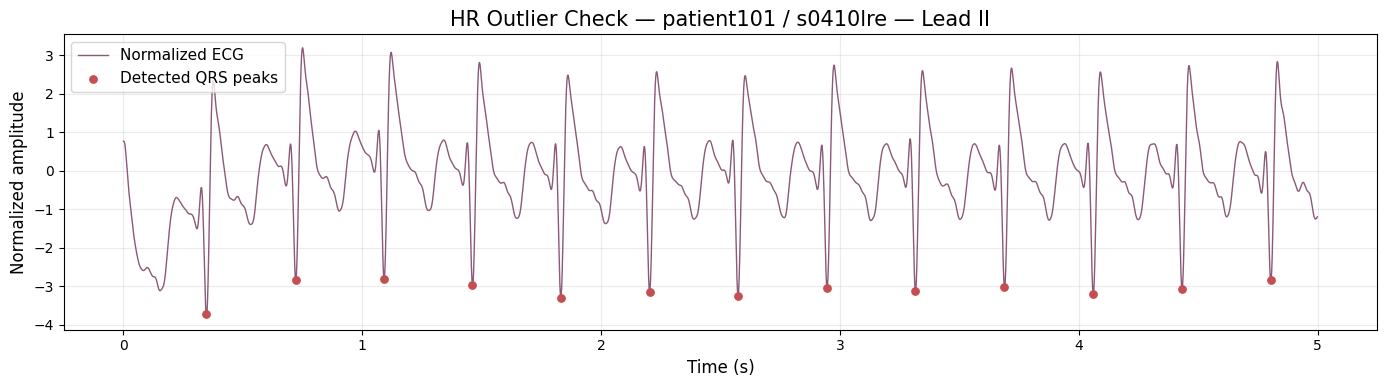

In [61]:
# =========================
# Visual inspection of HR outlier records
# =========================

def plot_qrs_peaks_for_record(row, start_sec=0, duration_sec=5, lead_name="ii"):
    raw_signal, fs, lead_names, record_info = load_ecg_record(row["record_path"])
    raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

    filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
        raw_12lead,
        fs,
        PREPROCESSING_CONFIG
    )

    lead_idx = selected_leads.index(lead_name.lower())
    lead_signal_for_detection = filtered_12lead[:, lead_idx]
    lead_signal_normalized = normalized_12lead[:, lead_idx]

    best_detection, _ = detect_r_peaks_neurokit_best_direction(
        lead_signal_for_detection,
        fs,
        method=SEGMENTATION_CONFIG["rpeak_detection_method"],
        correct_artifacts=SEGMENTATION_CONFIG["correct_artifacts"]
    )

    qrs_peaks = best_detection["r_peaks"]

    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    signal_seg = lead_signal_normalized[start_sample:end_sample]
    t = np.arange(len(signal_seg)) / fs + start_sec

    peaks_in_window = qrs_peaks[
        (qrs_peaks >= start_sample) & (qrs_peaks < end_sample)
    ]

    plt.figure(figsize=(14, 4))

    plt.plot(
        t,
        signal_seg,
        color=PURPLE_DARK,
        linewidth=1.0,
        label="Normalized ECG"
    )

    plt.scatter(
        peaks_in_window / fs,
        lead_signal_normalized[peaks_in_window],
        color=RED_SOFT,
        s=28,
        zorder=3,
        label="Detected QRS peaks"
    )

    plt.title(
        f"HR Outlier Check — {row['patient_id']} / {row['record_id']} — Lead {LEAD_DISPLAY_NAMES[lead_name]}"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


for _, row in hr_outliers_df.iterrows():
    plot_qrs_peaks_for_record(row, start_sec=0, duration_sec=5, lead_name="ii")

In [56]:
# =========================
# Count mutually exclusive feature groups
# =========================

metadata_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "rpeak_detection_direction"
]

label_cols = [
    "mi_detected",
    "healthy_control"
]

quality_cols = [
    "fs",
    "duration_sec",
    "n_samples",
    "n_channels_original",
    "n_detected_rpeaks",
    "n_valid_beats",
    "beat_length_samples"
]

all_cols = features_df.columns.tolist()

lead_specific_stat_cols = []
lead_specific_morph_cols = []
lead_specific_ratio_cols = []
rhythm_cols = []
lead_group_cols = []
lead_contrast_cols = []
other_cols = []

for col in all_cols:
    if col in metadata_cols or col in label_cols or col in quality_cols:
        continue

    if col.startswith("rhythm_"):
        rhythm_cols.append(col)

    elif col.startswith("contrast_"):
        lead_contrast_cols.append(col)

    elif "_group_" in col:
        lead_group_cols.append(col)

    elif "_stat_" in col:
        lead_specific_stat_cols.append(col)

    elif "_morph_" in col:
        lead_specific_morph_cols.append(col)

    elif "_ratio_" in col:
        lead_specific_ratio_cols.append(col)

    else:
        other_cols.append(col)

feature_group_counts = pd.DataFrame({
    "feature_group": [
        "lead_specific_statistical",
        "lead_specific_morphology",
        "lead_specific_ratio",
        "rhythm",
        "lead_group",
        "lead_contrast",
        "other"
    ],
    "n_features": [
        len(lead_specific_stat_cols),
        len(lead_specific_morph_cols),
        len(lead_specific_ratio_cols),
        len(rhythm_cols),
        len(lead_group_cols),
        len(lead_contrast_cols),
        len(other_cols)
    ]
})

display(feature_group_counts)

total_model_features = feature_group_counts["n_features"].sum()

print("Total model feature candidates:", total_model_features)
print("Quality/control columns:", len(quality_cols))
print("Label columns:", len(label_cols))
print("Metadata columns:", len(metadata_cols))
print("Total columns in features_df:", features_df.shape[1])

,feature_group,n_features
0,lead_specific_statistical,180
1,lead_specific_morphology,900
2,lead_specific_ratio,72
3,rhythm,14
4,lead_group,170
5,lead_contrast,70
6,other,0


Total model feature candidates: 1406
Quality/control columns: 7
Label columns: 2
Metadata columns: 7
Total columns in features_df: 1422


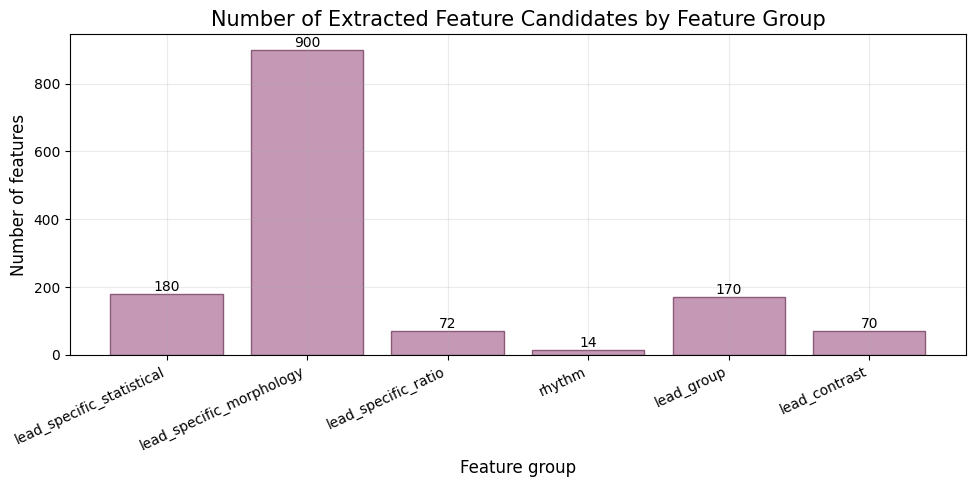

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook4_feature_group_counts.png


In [57]:
fig_path = FIGURE_DIR / "notebook4_feature_group_counts.png"

plot_df = feature_group_counts[feature_group_counts["n_features"] > 0].copy()

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["feature_group"],
    plot_df["n_features"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Number of Extracted Feature Candidates by Feature Group")
plt.xlabel("Feature group")
plt.ylabel("Number of features")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [58]:
features_output_path = FEATURE_DIR / "ptb_detection_handcrafted_features.csv"

features_df.to_csv(features_output_path, index=False, encoding="utf-8-sig")

print("Saved feature table to:")
print(features_output_path)
print("Shape:", features_df.shape)

Saved feature table to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features.csv
Shape: (448, 1422)


In [59]:
feature_group_counts_path = TABLE_DIR / "notebook4_feature_group_counts.csv"

feature_group_counts.to_csv(feature_group_counts_path, index=False, encoding="utf-8-sig")

print("Saved feature group counts to:")
print(feature_group_counts_path)

Saved feature group counts to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook4_feature_group_counts.csv
